<a href="https://colab.research.google.com/github/shuyu-d/IDL_TP/blob/master/tp3_idl_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP 3 (Exercice 3.5) - Calculs des gradients 

Dans ce TP, nous implémentons les fonctions pour le calcul des gradients de la fonction objective du problème de regression linéaire. 

Les données d'observation est généré aléatoirement par une fonction dédiée de Scikit-Learn (`sklearn`). 

In [1]:
import numpy as np
import pandas as pd
from sklearn import datasets, linear_model
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
%matplotlib inline



### Preparing the dataset

Dans cet example, on génère un jeu de données de manière aléatoire par `sklearn.datasets.make_regression`. Le nombre de variables dans $\bar{x}$ est $p=1$, et le nombre d'échantillons observés est $n=100$. 



In [2]:
np.random.seed(1)

# Xdata, y = datasets.make_regression(n_samples=30, n_features=1, noise=30) # 
Xdata, y = datasets.make_regression(n_samples=100, n_features=1, noise=30) # 

Observer une paritie du jeu de données avec l'aide de Pandas DataFrame. Les `DataFrame`s de Pandas sont souvent plus facile à visualiser que les structures de données de NumPy.


In [3]:
Xdata_pd = pd.DataFrame( Xdata )
Xdata_pd.head() # voir quelques lignes de la matrix Xdata

,0
0,-0.611756
1,-0.249370
2,0.488518
3,0.762011
4,1.519817


Visualiser les données d'observation. 

Text(0, 0.5, 'y')

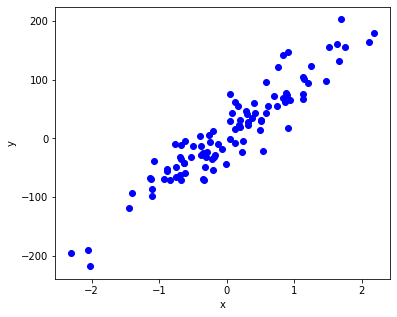

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))
ax.scatter(Xdata, y, marker='o', color='b')
ax.set_xlabel('x'); ax.set_ylabel('y')


### Dans le contexte de l'Exercice 2.7, calculer la solution du problème de régression linéaire 
Le modèle linéaire recherché est de la forme $ \bar{y} = {\beta^{\star}}^{T} \bar{x} + \epsilon$. Ici, dans le cas où $\bar{x}$ contient une seule variable prédictive ($p=1$), le produit scaliare entre $\beta^{\star}$ et $\bar{x}$ se réduit au simple produit $\beta^{\star} \bar{x}$ où le regresseur $\beta^{\star} \in \mathbb{R}$ représente la pente recherchée du modèle. 

In [5]:
n = Xdata.shape[0]
# ajuster la matrice Xdata 
print(r'A few rows of the matrix X for linear regression, with the column $(1,..,1)^T$ appended to the design matrix of the dataset:')
X = np.hstack((np.ones((n,1)), Xdata)) 
pd.DataFrame(X).head() 

A few rows of the matrix X for linear regression, with the column $(1,..,1)^T$ appended to the design matrix of the dataset:


,0,1
0,1.0,-0.611756
1,1.0,-0.249370
2,1.0,0.488518
3,1.0,0.762011
4,1.0,1.519817


In [6]:
def beta_closed_form(X, y):
    # implémenter l'expression explicite de la solution recherchée 
    # inv = np.linalg.pinv(X.T.dot(X)) # utile 
    inv = np.linalg.inv(X.T.dot(X))
    beta = inv.dot(X.T).dot(y)
    return beta

beta_closedform = beta_closed_form(X, y)
print(beta_closedform.shape) # expected shape: (2,)
print(beta_closedform)

(2,)
[ 6.08104317 83.37148916]


**Visualiser** la solution : 

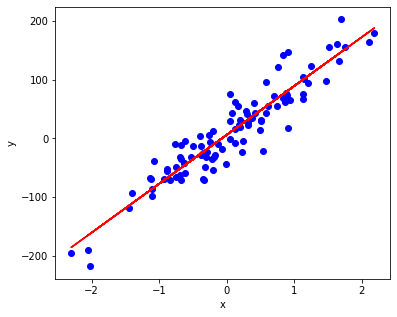

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))
ax.scatter(X[:,1], y, marker='o', color='b')
ax.plot(X[:,1], X.dot(beta_closedform), color='r')
ax.set_xlabel('x'); ax.set_ylabel('y')

# fig, ax = plt.subplots(1, 1, figsize=(4,7))
# ax.scatter(X[:,1], y, marker='o', color='k')
# ax.plot(X[:,1], X.dot(beta_closedform), color='b')
# ax.grid()
# ax.set_xlabel('x'); ax.set_ylabel('y')
fig.savefig('out4_linreg.pdf', format='pdf', bbox_inches = 'tight')


Visualiser la solution sur le plan montrant les lignes de niveau de la fonction d'objective : 

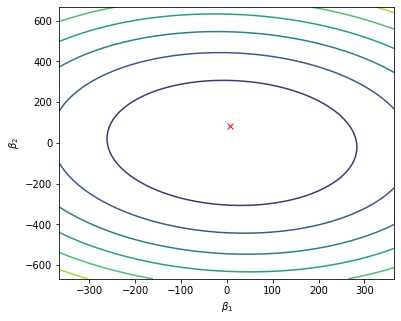

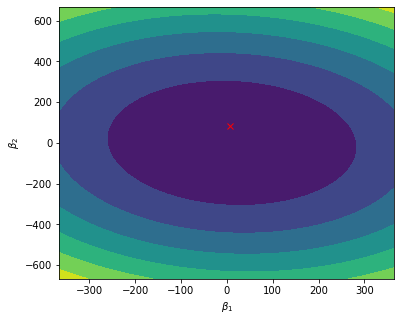

In [17]:
def compute_cost_one_variable(X, y, beta):
    n = y.shape[0]
    # J = (1/(2*n)) * (np.sum((X.dot(beta) - y)**2))
    J = (np.sum((X.dot(beta) - y)**2))
    return J
beta0_vals = np.linspace(beta_closedform[0]*(-60), beta_closedform[0]*60, 100)
beta1_vals = np.linspace(beta_closedform[1]*(-8), beta_closedform[1]*8, 100)
J_vals = np.zeros(shape=(len(beta0_vals), len(beta1_vals)))
for i in range(0, len(beta0_vals)):
    for j in range(0, len(beta1_vals)):
        J_vals[i,j] = compute_cost_one_variable(X, y, [[beta0_vals[i]], [beta1_vals[j]]])

fig, ax = plt.subplots(1, 1, figsize=(6,5))
ax.contour(beta0_vals, beta1_vals, np.transpose(J_vals))
ax.plot(beta_closedform[0], beta_closedform[1], marker='x', color='r');
ax.set_xlabel(r'$\beta_1$'); ax.set_ylabel(r'$\beta_2$')
fig.savefig('out4_linregContour.pdf', format='pdf', bbox_inches = 'tight')

fig, ax = plt.subplots(1, 1, figsize=(6,5))
ax.contourf(beta0_vals, beta1_vals, np.transpose(J_vals))
ax.plot(beta_closedform[0], beta_closedform[1], marker='x', color='r');
ax.set_xlabel(r'$\beta_1$'); ax.set_ylabel(r'$\beta_2$')
fig.savefig('tp3_linregContourf.pdf', format='pdf', bbox_inches = 'tight')


### Exercice 3.5 
Le modèle linéaire recherché est de la forme $ \bar{y} = {\beta^{\star}}^{T} \bar{x} + \epsilon$. Ici, dans le cas où $\bar{x}$ contient une seule variable prédictive ($p=1$), le produit scaliare entre $\beta^{\star}$ et $\bar{x}$ se réduit au simple produit $\beta^{\star} \bar{x}$ où le regresseur $\beta^{\star} \in \mathbb{R}$ représente la pente recherchée du modèle.

**Question (i):** A l'aide du résultat de l'Exercice 3.2, montrer que la fonction objective $f$ de ce problème est dérivable. En même temps, donner l'expression du gradient de $f$ en $\beta\in\mathbb{R}^2$.

Remplir la fonction `compute_gradient(X, y, beta)`. 


In [18]:
def compute_gradient(X, y, beta): 
    grad = 2 *( (X.T.dot(X)) @ beta - (X.T)@y )
    return grad

#### Visualisation de gradients $\text{grad}f(\beta)$ sur quelques points 

In [19]:


betas = []
beta_ = np.array([-beta_closedform[0]*25, beta_closedform[1]*8])
betas.append(beta_)

beta_ = np.array([beta_closedform[0]*25, beta_closedform[1]*8])
betas.append(beta_)

beta_ = np.array([-beta_closedform[0]*20, beta_closedform[1]*4])
betas.append(beta_)

beta_ = np.array([beta_closedform[0]*20, beta_closedform[1]*4])
betas.append(beta_)

beta_ = np.array([-beta_closedform[0]*25, -beta_closedform[1]*8])
betas.append(beta_)

beta_ = np.array([beta_closedform[0]*25, -beta_closedform[1]*8])
betas.append(beta_)

beta_ = np.array([-beta_closedform[0]*20, -beta_closedform[1]*4])
betas.append(beta_)

beta_ = np.array([beta_closedform[0]*20, -beta_closedform[1]*4])
betas.append(beta_)



#ngrads1 =  np.zeros(shape=(len(betas[0]), len(betas[1])))
#ngrads2 =  np.zeros(shape=(len(betas[0]), len(betas[1])))
ngrads = []
for i in range(0, len(betas) ):
        #J_vals[i,j] = compute_cost_one_variable(X, y, [[beta0_vals[i]], [beta1_vals[j]]])
        grad = compute_gradient(X, y, betas[i]  )
        if i == 0:
            n0 = np.linalg.norm(grad)
        ngrad = -100 * grad / n0
        ngrads.append( ngrad )


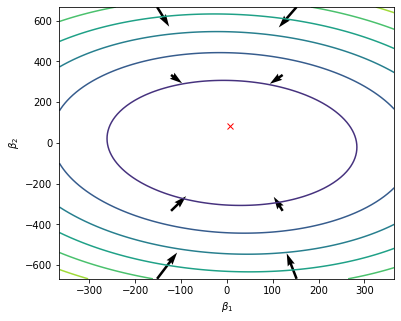

In [20]:
betas = np.array(betas)
ngrads = np.array(ngrads)

# print(J_vals)
fig, ax = plt.subplots(1, 1, figsize=(6,5))
ax.contour(beta0_vals, beta1_vals, np.transpose(J_vals))
ax.plot(beta_closedform[0], beta_closedform[1], marker='x', color='r');
ax.set_xlabel(r'$\beta_1$'); ax.set_ylabel(r'$\beta_2$')


ax.quiver(betas[:,0], betas[:,1], ngrads[:,0], ngrads[:,1],
            angles='xy', scale_units='xy', scale=1, color='k', alpha=1)
fig.savefig('tp3_contour_grad.pdf', format='pdf', \
             transparent=True, bbox_inches = 'tight')

** Question (ii) :** Donner votre observation de la visualisation des gradients sur les points donnés. En particulier, expliquer la tendance des normes de ces gradients par rapport à leur positions sur le plan.